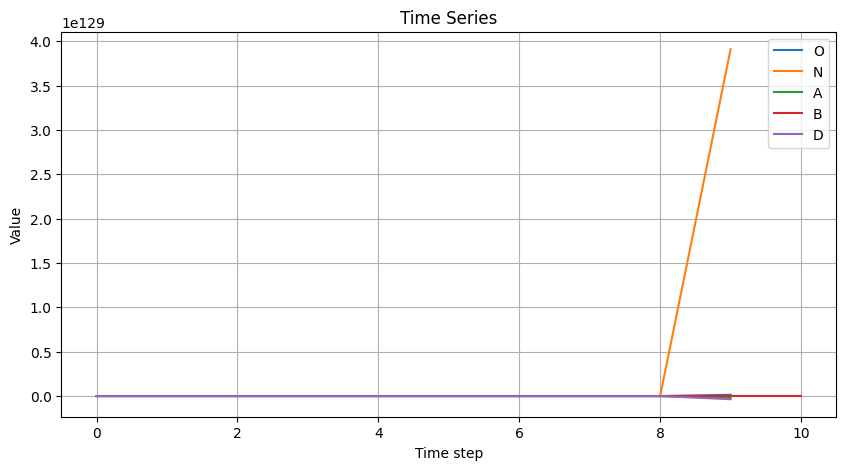

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS (set here)
# =========================
T = 3000  # number of time steps

# Initial conditions
O = 20.86
N = 0.55
A = 1.0
B = 0.5
D = 2.0

# Model parameters
h = 0.5
dl = 0.1
m1 = 0.02
eps = 0.05

d1 = 0.3
n0 = 10
k1 = 5.5
d2 = 0.15

e = 0.2
c1 = 0.03
gam1 = 0.4
b2 = 2.0

pexp = 1
e2 = 0.25
gam2 = 0.3
eta1 = 0.2

f1 = 0.05
g = 0.1
f2 = 0.08

# =========================
# STORAGE
# =========================
O_vals = np.zeros(T)
N_vals = np.zeros(T)
A_vals = np.zeros(T)
B_vals = np.zeros(T)
D_vals = np.zeros(T)

# =========================
# ITERATION
# =========================
for t in range(T):

    # store current values
    O_vals[t] = O
    N_vals[t] = N
    A_vals[t] = A
    B_vals[t] = B
    D_vals[t] = D

    # common term
    sw = 1 / (1 + (O/b2)**pexp);

    # compute next step
    O_next = (
        h*D - dl*O - m1*O*N*A - eps*O
    )

    N_next = (
        d1*(n0 - N) - k1*O*N*A - d2*B*N
    )

    A_next = (
        -e*A + c1*O*N*A - gam1*sw*A
    )

    B_next = (
        -e2*B + gam2*sw*A + eta1*sw*B*N
    )

    D_next = (
        f1*O*N*A - g*D + f2*B*N
    )

    # update variables
    O = O_next
    N = N_next
    A = A_next
    B = B_next
    D = D_next

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,5))
plt.plot(O_vals, label="O")
plt.plot(N_vals, label="N")
plt.plot(A_vals, label="A")
plt.plot(B_vals, label="B")
plt.plot(D_vals, label="D")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.title("Time Series")
plt.show()

In [9]:
from scipy.integrate import solve_ivp   # replaces odeint
import scipy.optimize as opt
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from joblib import Parallel, delayed

# Mimic their Struct class — lets you use p.h instead of p[0]
class Struct:
    def __init__(self, **entries):
        self.__dict__.update(entries)

# Your parameters as a Struct
p = Struct(
    h=0.5,   dl=0.1,  m1=0.02, eps=0.05,
    d1=0.3,  n0=10,   k1=5.5,  d2=0.15,
    e=0.2,   c1=0.03, gam1=0.4, b2=2.0, pexp=1,
    e2=0.25, gam2=0.3, eta1=0.2,
    f1=0.05, g=0.1,   f2=0.08
)

In [10]:
def pitcher_odes(t, y, p):
    O, N, A, B, D = y
    sw = 1 / (1 + (O/p.b2)**p.pexp)
    dO = p.h*D - p.dl*O - p.m1*O*N*A - p.eps*O
    dN = p.d1*(p.n0 - N) - p.k1*O*N*A - p.d2*B*N
    dA = -p.e*A + p.c1*O*N*A - p.gam1*sw*A
    dB = -p.e2*B + p.gam2*sw*A + p.eta1*sw*B*N
    dD = p.f1*O*N*A - p.g*D + p.f2*B*N
    return [dO, dN, dA, dB, dD]

def run_sim(p):
    y0 = [20.86, 0.55, 1.0, 0.5, 2.0]
    sol = solve_ivp(pitcher_odes, [0, 3000], y0, args=(p,),
                    method='RK45', rtol=1e-8, atol=1e-10, max_step=1.0)
    return sol

# --- Sliders (mirrors their tkinter Scale widgets) ---
h_sl   = widgets.FloatSlider(min=0.01, max=1.5,  value=0.5,  step=0.01, description='h',   continuous_update=False)
f1_sl  = widgets.FloatSlider(min=0.01, max=0.3,  value=0.05, step=0.005,description='f1',  continuous_update=False)
k1_sl  = widgets.FloatSlider(min=0.01, max=8.0,  value=5.5,  step=0.05, description='k1',  continuous_update=False)
N0_sl  = widgets.FloatSlider(min=1.0,  max=20.0, value=10.0, step=0.5,  description='N0',  continuous_update=False)
d1_sl  = widgets.FloatSlider(min=0.01, max=1.0,  value=0.3,  step=0.01, description='d1',  continuous_update=False)

out = widgets.Output()

def update_plot(change):
    with out:
        out.clear_output(wait=True)

        # Build Struct from slider values (mirrors their tkinter .get())
        p = Struct(
            h=h_sl.value,  dl=0.1,  m1=0.02,  eps=0.05,
            d1=d1_sl.value, n0=N0_sl.value, k1=k1_sl.value, d2=0.15,
            e=0.2,  c1=0.03, gam1=0.4, b2=2.0, pexp=1,
            e2=0.25, gam2=0.3, eta1=0.2,
            f1=f1_sl.value, g=0.1, f2=0.08
        )

        sol = run_sim(p)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(sol.t, sol.y[0], label='O', linewidth=2)
        ax.plot(sol.t, sol.y[1], label='N', linewidth=2)
        ax.plot(sol.t, sol.y[2], label='A', linewidth=2)
        ax.plot(sol.t, sol.y[3], label='B', linewidth=2)
        ax.plot(sol.t, sol.y[4], label='D', linewidth=2)
        ax.set_xlabel('Time'); ax.set_ylabel('Value')
        ax.set_title('Pitcher Plant Model'); ax.legend(); ax.grid(True)
        plt.tight_layout(); plt.show()

# Attach update to every slider
for sl in [h_sl, f1_sl, k1_sl, N0_sl, d1_sl]:
    sl.observe(update_plot, names='value')

display(widgets.VBox([h_sl, f1_sl, k1_sl, N0_sl, d1_sl, out]))
update_plot(None)  # draw on startup